# Transformer 模型训练和评估


## 介绍

前面的章节中，我们介绍了 Transformer 模型的基本结构和工作原理，并实现一个完整的基于 Transformer 模型的加法计算模型。在这一章节中，我们将重点关注 Transformer 模型的训练和评估过程。

## 环境配置

### 安装依赖

In [ ]:
!pip install --upgrade dsxllm

### 环境版本

In [1]:
from dsxllm.util import show_version

show_version()

/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


本书愿景：
+------+--------------------------------------------------------+
| Info |                  《动手学大语言模型》                  |
+------+--------------------------------------------------------+
| 作者 |                       吾辈亦有感                       |
| 哔站 |      https://space.bilibili.com/3546632320715420       |
| 定位 | 基于'从零构建'的理念，用实战帮助程序员快速入门大模型。 |
| 愿景 | 若让你的AI学习之路走的更容易一点，我将倍感荣幸！祝好😄 |
+------+--------------------------------------------------------+
环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.10.0    |         2.6.1          |
+-------------+--------------+------------------------+


## 初始化模型和训练器

In [2]:
from dsxllm.transformer.tokenizer import get_tokenizer
from dsxllm.transformer.dataset import TextTransform, TextDataModule
from dsxllm.transformer.model import Transformer

import lightning as L

# 超参配置
encoder_max_length = 7  # 编码器输入最大长度
decoder_max_length = 6  # 解码器输入最大长度

batch_size = 100  # 批次大小
d_model = 128  # 模型维度
feedforward_size = 512  # 前馈神经网络维度
n_layers = 4  # 编码器和解码器层数
learning_rate = 0.0001  # 学习率


# 1️⃣ 初始化分词器
tokenizer = get_tokenizer()

# 2️⃣ 初始化编码器和解码器的数据转换器
encoder_transform = TextTransform(tokenizer, max_length=encoder_max_length)
decoder_transform = TextTransform(tokenizer, max_length=decoder_max_length)

# 3️⃣ 加载数据模组
datamodule = TextDataModule(
    batch_size=batch_size,
    encoder_transform=encoder_transform,
    decoder_transform=decoder_transform,
    train_data_file="./dataset/addition_train.txt",
    val_data_file="./dataset/addition_val.txt",
)

# 4️⃣ 初始化模型
model = Transformer(
    tokenizer,
    d_model,
    feedforward_size,
    n_layers=n_layers,
    learning_rate=learning_rate,
    encoder_max_length=encoder_max_length,
    decoder_max_length=decoder_max_length - 1,
)

# 5️⃣ 初始化训练器
trainer = L.Trainer(
    max_epochs=12,  # 最大训练轮数
    log_every_n_steps=3,  # 每 3 个批次打印一次日志
    check_val_every_n_epoch=1,  # 每轮训练验证一次
    num_sanity_val_steps=0,  # 训练前不进行验证
    enable_progress_bar=False,  # 不显示进度条
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## 训练前评估

训练前评估为模型性能建立初始性能基准。

In [3]:
# 直接调用验证函数进行评估
trainer.validate(model=model, datamodule=datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


***** Validation: 样本总数 5000  正确预测: 0  正确率: 0.0000 *****


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     correct_sequences     │            0.0            │
│      correct_tokens       │           705.0           │
│          seq_acc          │            0.0            │
│         token_acc         │    0.03403495252132416    │
│      total_sequences      │          5000.0           │
│       total_tokens        │          20714.0          │
└───────────────────────────┴───────────────────────────┘

[{'total_sequences': 5000.0,
  'correct_sequences': 0.0,
  'seq_acc': 0.0,
  'total_tokens': 20714.0,
  'correct_tokens': 705.0,
  'token_acc': 0.03403495252132416}]

## 训练模型

调用 `trainer.fit()` 训练 12 个轮次。

In [4]:
model.clear_cache()
trainer.fit(model=model, datamodule=datamodule)

┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃  FLOPs ┃                      In sizes ┃   Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 0 │ encoder │ Encoder │  987 K │ train │ 27.7 M │                        [2, 7] │ [2, 7, 128] │
│ 1 │ decoder │ Decoder │  1.2 M │ train │ 24.9 M │ [[2, 5], [2, 7], [2, 7, 128]] │  [2, 5, 16] │
└───┴─────────┴─────────┴────────┴───────┴────────┴───────────────────────────────┴─────────────┘

Trainable params: 2.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.2 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 125                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 52.7 M

***** Validation: 样本总数 5000  正确预测: 76  正确率: 0.0152 *****
***** 【Epoch 0】  Train Avg Loss: 1.4259 *****
***** Validation: 样本总数 5000  正确预测: 1124  正确率: 0.2248 *****
***** 【Epoch 1】  Train Avg Loss: 1.0204 *****
***** Validation: 样本总数 5000  正确预测: 4582  正确率: 0.9164 *****
***** 【Epoch 2】  Train Avg Loss: 0.2894 *****
***** Validation: 样本总数 5000  正确预测: 4983  正确率: 0.9966 *****
***** 【Epoch 3】  Train Avg Loss: 0.0340 *****
***** Validation: 样本总数 5000  正确预测: 4999  正确率: 0.9998 *****
***** 【Epoch 4】  Train Avg Loss: 0.0043 *****
***** Validation: 样本总数 5000  正确预测: 5000  正确率: 1.0000 *****
***** 【Epoch 5】  Train Avg Loss: 0.0020 *****
***** Validation: 样本总数 5000  正确预测: 5000  正确率: 1.0000 *****
***** 【Epoch 6】  Train Avg Loss: 0.0012 *****
***** Validation: 样本总数 5000  正确预测: 5000  正确率: 1.0000 *****
***** 【Epoch 7】  Train Avg Loss: 0.0008 *****
***** Validation: 样本总数 5000  正确预测: 5000  正确率: 1.0000 *****
***** 【Epoch 8】  Train Avg Loss: 0.0006 *****
***** Validation: 样本总数 5000  正确预测: 5000  正确率: 1.0000 ****

`Trainer.fit` stopped: `max_epochs=12` reached.


***** Validation: 样本总数 5000  正确预测: 5000  正确率: 1.0000 *****
***** 【Epoch 11】  Train Avg Loss: 0.0003 *****


### 训练过程可视化
绘制训练过程中损失值的变化曲线。

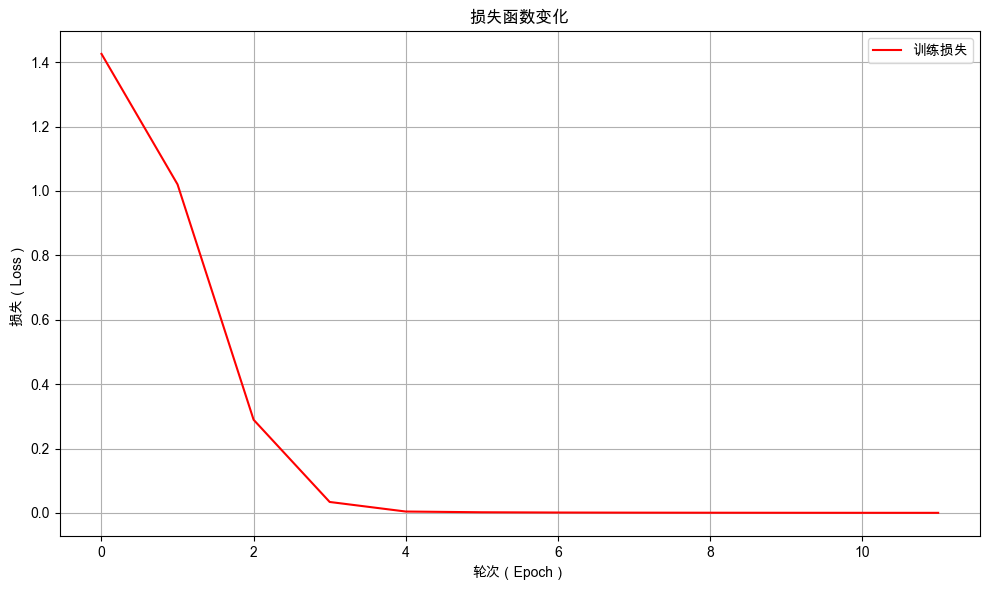

In [6]:
from dsxllm.util import plot_loss_curves

plot_loss_curves(model.train_epoch_losses)

### 查看模型评估记录

查看训练过程中的评估结果，观察模型在验证集上的表现。

In [7]:
from dsxllm.util import to_dataframe

df = to_dataframe(model.validation_epoch_outputs)

display(df)

,epoch,总样本数,正确样本数,样本准确率,总Token数,正确Token数,Token准确率
0,0,5000,76,0.0152,20714,9495,0.4584
1,1,5000,1124,0.2248,20714,14741,0.7116
2,2,5000,4582,0.9164,20714,20287,0.9794
3,3,5000,4983,0.9966,20714,20697,0.9992
4,4,5000,4999,0.9998,20714,20713,1.0000
5,5,5000,5000,1.0000,20714,20714,1.0000
6,6,5000,5000,1.0000,20714,20714,1.0000
7,7,5000,5000,1.0000,20714,20714,1.0000
8,8,5000,5000,1.0000,20714,20714,1.0000
9,9,5000,5000,1.0000,20714,20714,1.0000


## 训练后评估

与训练前的评估结果对比，确认模型训练效果是否有效。

In [8]:
# 直接调用验证函数进行评估
trainer.validate(model=model, datamodule=datamodule)

/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


***** Validation: 样本总数 5000  正确预测: 5000  正确率: 1.0000 *****


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     correct_sequences     │          5000.0           │
│      correct_tokens       │          20714.0          │
│          seq_acc          │            1.0            │
│         token_acc         │            1.0            │
│      total_sequences      │          5000.0           │
│       total_tokens        │          20714.0          │
└───────────────────────────┴───────────────────────────┘

[{'total_sequences': 5000.0,
  'correct_sequences': 5000.0,
  'seq_acc': 1.0,
  'total_tokens': 20714.0,
  'correct_tokens': 20714.0,
  'token_acc': 1.0}]

## 使用模型进行预测

使用一些测试算式进行推理预测，直观观察模型的预测效果。

In [9]:
from dsxllm.util import print_generation_predictions

# 1️⃣ 创建一些测试问题和答案
questions = ["829+33", "58+136", "22+593", "243+269", "1+1"]
answers = ["862", "194", "615", "512", "2"]

# 2️⃣ 使用与训练时统一的数据处理方法对输入进行处理
question_encoded = encoder_transform(questions)
encoder_input_ids = question_encoded["input_ids"]

# 3️⃣ 使用模型进行预测
generated_texts = model.generate_batch(encoder_input_ids)

# 4️⃣ 输出预测结果
print_generation_predictions(questions, answers, generated_texts)

🎯 生成结果 (准确率: 5/5 = 100.00%)：
+---------+--------+--------+------+
|   输入  | 真实值 | 预测值 | 标记 |
+---------+--------+--------+------+
|  829+33 |  862   |  862   |  ☑   |
|  58+136 |  194   |  194   |  ☑   |
|  22+593 |  615   |  615   |  ☑   |
| 243+269 |  512   |  512   |  ☑   |
|   1+1   |   2    |   2    |  ☑   |
+---------+--------+--------+------+


## 本章小结


我们已经完成了使用 Transformer 重构加法计算模型的工作。经过训练和评估，新模型在评估集上的准确率达到了 100%。通过这个`小任务`，我们亲手实现了 Transformer 的所有组件，深入透彻地掌握了其工作原理，并深刻体会到从循环神经网络到 Transformer 的革命性飞跃。掌握 Transformer，就相当于掌握了破解现代大语言模型的钥匙。从下一章开始，我们将正式开启大语言模型的新篇章。

## 答疑讨论

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('qa'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">答疑讨论</h4>
                <p class="card-text">
                    如果你有任何学习上的疑问，可以评论留言，和我一起讨论。我会抽空回复你的问题，也欢迎你回答其他人的问题。
                </p>
            </div>
        </div>
    </div>
</a>
```